# PCA non corrigée de GSE149689

Construction et diagnostic d'une PCA sur les 2 000 HVG, sans correction de batch ni régression de covariables.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
from IPython.display import Markdown, display

## Chargement et contrôles

In [2]:
adata = sc.read_h5ad("../data/processed/GSE149689_log_normalized.h5ad")
figure_dir = Path("../results/figures/pca")
table_dir = Path("../results/tables/pca")
figure_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

counts_layer = adata.layers["counts"] if "counts" in adata.layers else None
initial_checks = {
    "dimensions_58825_x_33538": adata.shape == (58825, 33538),
    "exactly_2000_HVG": "highly_variable" in adata.var and int(adata.var["highly_variable"].sum()) == 2000,
    "20_sample_id": "sample_id" in adata.obs and adata.obs["sample_id"].nunique() == 20,
    "log1p_metadata_present": "log1p" in adata.uns,
    "counts_layer_present": counts_layer is not None,
    "counts_layer_sparse": sparse.issparse(counts_layer),
    "raw_counts_nonnegative": counts_layer is not None and bool(np.all(counts_layer.data >= 0)),
    "raw_counts_integer_valued": counts_layer is not None and bool(np.all(np.equal(counts_layer.data, np.floor(counts_layer.data)))),
}
print(adata)
display(pd.Series(initial_checks, name="passed").to_frame())
if not all(initial_checks.values()):
    raise AssertionError(f"Échec des contrôles initiaux : {initial_checks}")

AnnData object with n_obs × n_vars = 58825 × 33538
    obs: 'sample_id', 'subject_id', 'disease', 'severity', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p'
    layers: 'counts'


,passed
dimensions_58825_x_33538,True
exactly_2000_HVG,True
20_sample_id,True
log1p_metadata_present,True
counts_layer_present,True
counts_layer_sparse,True
raw_counts_nonnegative,True
raw_counts_integer_valued,True


## Copie HVG et scaling

In [3]:
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
if adata_hvg.shape != (58825, 2000):
    raise AssertionError(f"Dimensions HVG inattendues : {adata_hvg.shape}")

sc.pp.scale(
    adata_hvg,
    zero_center=True,
    max_value=10,
)

scaled_gene_means = np.asarray(adata_hvg.X.mean(axis=0)).ravel()
scaled_gene_stds = np.asarray(adata_hvg.X.std(axis=0)).ravel()
scale_diagnostics = pd.Series({
    "median_absolute_gene_mean_after_clipping": np.median(np.abs(scaled_gene_means)),
    "maximum_absolute_gene_mean_after_clipping": np.max(np.abs(scaled_gene_means)),
    "median_gene_sd_after_clipping": np.median(scaled_gene_stds),
    "Q1_gene_sd_after_clipping": np.quantile(scaled_gene_stds, 0.25),
    "Q3_gene_sd_after_clipping": np.quantile(scaled_gene_stds, 0.75),
    "minimum_scaled_value": np.min(adata_hvg.X),
    "maximum_scaled_value": np.max(adata_hvg.X),
}, name="value")
display(scale_diagnostics.to_frame())

scale_checks = {
    "dimensions_unchanged": adata_hvg.shape == (58825, 2000),
    "gene_means_approximately_zero": float(np.median(np.abs(scaled_gene_means))) < 0.1,
    "gene_sd_approximately_one_after_clipping": 0.8 <= float(np.median(scaled_gene_stds)) <= 1.05,
    "values_at_least_minus_10": float(np.min(adata_hvg.X)) >= -10.0001,
    "values_at_most_plus_10": float(np.max(adata_hvg.X)) <= 10.0001,
    "pre_clipping_sd_recorded": "std" in adata_hvg.var and bool(np.all(adata_hvg.var["std"] > 0)),
}
display(pd.Series(scale_checks, name="passed").to_frame())
if not all(scale_checks.values()):
    raise AssertionError(f"Échec des contrôles de scaling : {scale_checks}")

/home/momo/miniconda3/envs/scrna/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


,value
median_absolute_gene_mean_after_clipping,0.000014
maximum_absolute_gene_mean_after_clipping,0.022970
median_gene_sd_after_clipping,0.999845
Q1_gene_sd_after_clipping,0.945404
Q3_gene_sd_after_clipping,0.999992
minimum_scaled_value,-4.851129
maximum_scaled_value,10.000000


,passed
dimensions_unchanged,True
gene_means_approximately_zero,True
gene_sd_approximately_one_after_clipping,True
values_at_least_minus_10,True
values_at_most_plus_10,True
pre_clipping_sd_recorded,True


## PCA à 50 composantes

In [4]:
sc.pp.pca(
    adata_hvg,
    n_comps=50,
    svd_solver="arpack",
    random_state=42,
)

pca_checks = {
    "X_pca_shape": adata_hvg.obsm["X_pca"].shape == (58825, 50),
    "loadings_present": "PCs" in adata_hvg.varm and adata_hvg.varm["PCs"].shape == (2000, 50),
    "variance_ratios_present": "pca" in adata_hvg.uns and len(adata_hvg.uns["pca"]["variance_ratio"]) == 50,
    "no_cells_removed": adata_hvg.n_obs == adata.n_obs == 58825,
}
display(pd.Series(pca_checks, name="passed").to_frame())
if not all(pca_checks.values()):
    raise AssertionError(f"Échec des contrôles PCA : {pca_checks}")

,passed
X_pca_shape,True
loadings_present,True
variance_ratios_present,True
no_cells_removed,True


## Variance expliquée

,PC,variance_explained,variance_explained_percent,cumulative_variance,cumulative_variance_percent
0,PC1,0.097350,9.734973,0.097350,9.734973
1,PC2,0.041524,4.152426,0.138874,13.887399
2,PC3,0.027388,2.738772,0.166262,16.626171
3,PC4,0.018802,1.880218,0.185064,18.506389
4,PC5,0.013100,1.310037,0.198164,19.816426
5,PC6,0.010410,1.041023,0.208574,20.857449
6,PC7,0.008666,0.866615,0.217241,21.724063
7,PC8,0.006661,0.666082,0.223901,22.390145
8,PC9,0.006312,0.631182,0.230213,23.021327
9,PC10,0.005614,0.561437,0.235828,23.582764


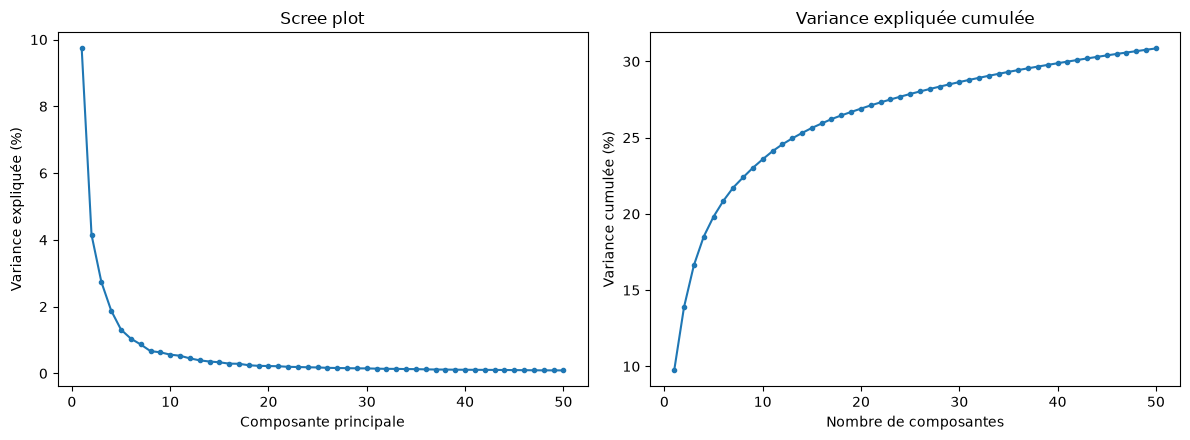

In [5]:
variance_ratio = np.asarray(adata_hvg.uns["pca"]["variance_ratio"])
cumulative_variance = np.cumsum(variance_ratio)
variance_table = pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, 51)],
    "variance_explained": variance_ratio,
    "variance_explained_percent": 100 * variance_ratio,
    "cumulative_variance": cumulative_variance,
    "cumulative_variance_percent": 100 * cumulative_variance,
})
display(variance_table.head(20))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(range(1, 51), 100 * variance_ratio, marker="o", markersize=3)
axes[0].set_xlabel("Composante principale")
axes[0].set_ylabel("Variance expliquée (%)")
axes[0].set_title("Scree plot")
axes[1].plot(range(1, 51), 100 * cumulative_variance, marker="o", markersize=3)
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance cumulée (%)")
axes[1].set_title("Variance expliquée cumulée")
fig.tight_layout()
fig.savefig(figure_dir / "pca_variance_explained.png", dpi=300, bbox_inches="tight")
plt.show()

## Gènes dominants dans PC1 à PC10

In [6]:
loadings = adata_hvg.varm["PCs"]
loading_rows = []
for pc_index in range(10):
    pc_loadings = loadings[:, pc_index]
    positive_positions = np.argsort(pc_loadings)[-10:][::-1]
    negative_positions = np.argsort(pc_loadings)[:10]
    for direction, positions in [("positive", positive_positions), ("negative", negative_positions)]:
        for rank, position in enumerate(positions, start=1):
            loading_rows.append({
                "PC": f"PC{pc_index + 1}",
                "direction": direction,
                "rank": rank,
                "gene_name": adata_hvg.var_names[position],
                "loading": pc_loadings[position],
            })
pca_top_loadings = pd.DataFrame(loading_rows)
pca_top_loadings.to_csv(table_dir / "pca_top_loadings.csv", index=False)
display(pca_top_loadings)
print("Table sauvegardée :", table_dir / "pca_top_loadings.csv")

,PC,direction,rank,gene_name,loading
0,PC1,positive,1,FCN1,0.069498
1,PC1,positive,2,LYZ,0.068751
2,PC1,positive,3,AIF1,0.067567
3,PC1,positive,4,SERPINA1,0.067013
4,PC1,positive,5,CTSS,0.066629
...,...,...,...,...,...
195,PC10,negative,6,HBM,-0.084952
196,PC10,negative,7,HBA1,-0.082820
197,PC10,negative,8,HBB,-0.074852
198,PC10,negative,9,GLRX5,-0.070869


Table sauvegardée : ../results/tables/pca/pca_top_loadings.csv


## Corrélations entre PC1-PC10 et métriques QC

In [7]:
pc_names = [f"PC{i}" for i in range(1, 11)]
qc_metrics = ["total_counts", "n_genes_by_counts", "pct_counts_mt"]
pc_qc_data = pd.DataFrame(adata_hvg.obsm["X_pca"][:, :10], index=adata_hvg.obs_names, columns=pc_names)
pc_qc_data = pd.concat([pc_qc_data, adata_hvg.obs[qc_metrics]], axis=1)
pc_qc_spearman = pc_qc_data.corr(method="spearman").loc[pc_names, qc_metrics]
display(pc_qc_spearman)

,total_counts,n_genes_by_counts,pct_counts_mt
PC1,0.379577,0.413876,-0.081069
PC2,-0.368475,-0.484101,-0.037048
PC3,0.112125,-0.052682,0.003642
PC4,0.437632,0.444187,-0.105879
PC5,0.094848,0.216880,-0.061270
PC6,0.206021,0.096781,-0.071724
PC7,-0.336075,-0.282913,0.028816
PC8,-0.030227,-0.030266,-0.151730
PC9,0.009080,0.021837,0.063436
PC10,-0.195901,-0.207570,0.083313


## Projections PCA non corrigées

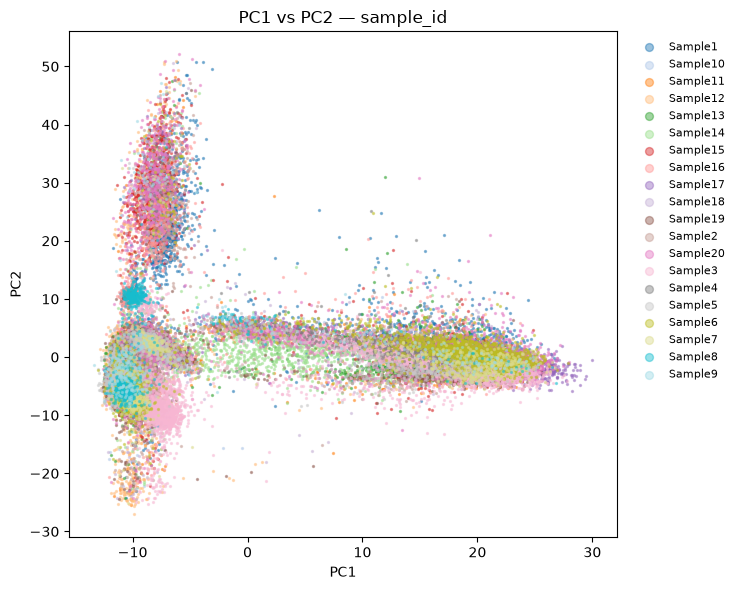

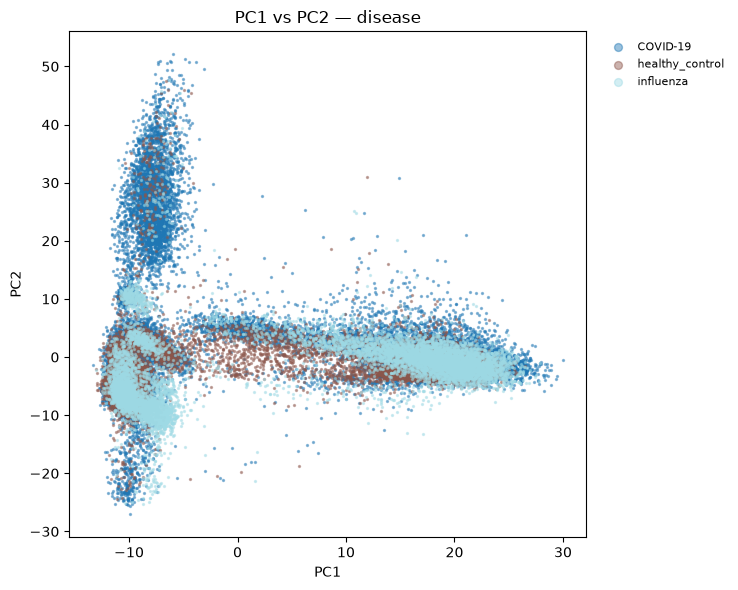

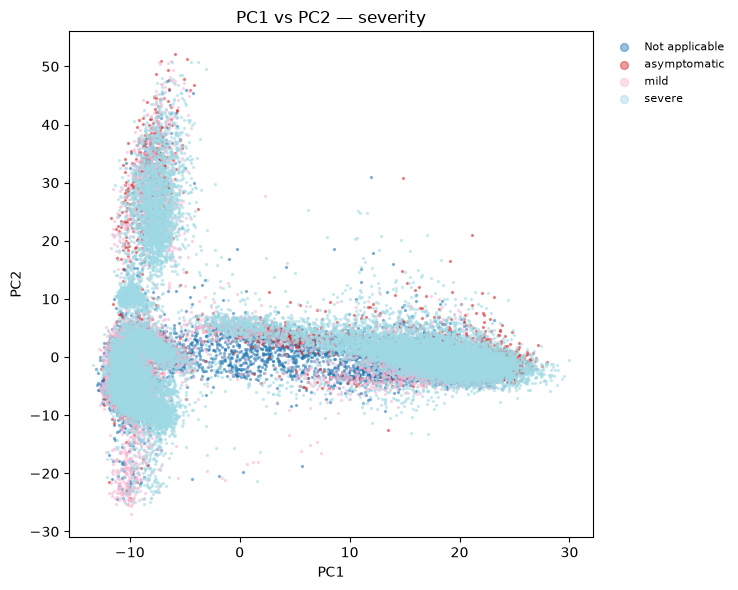

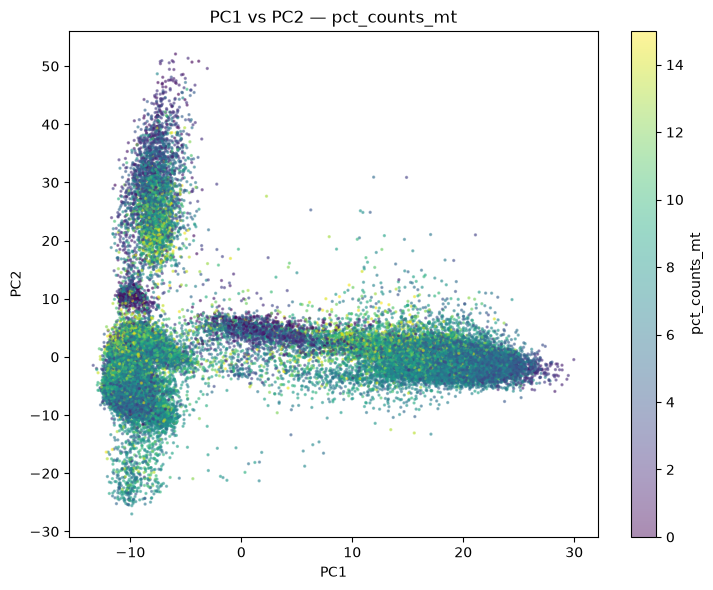

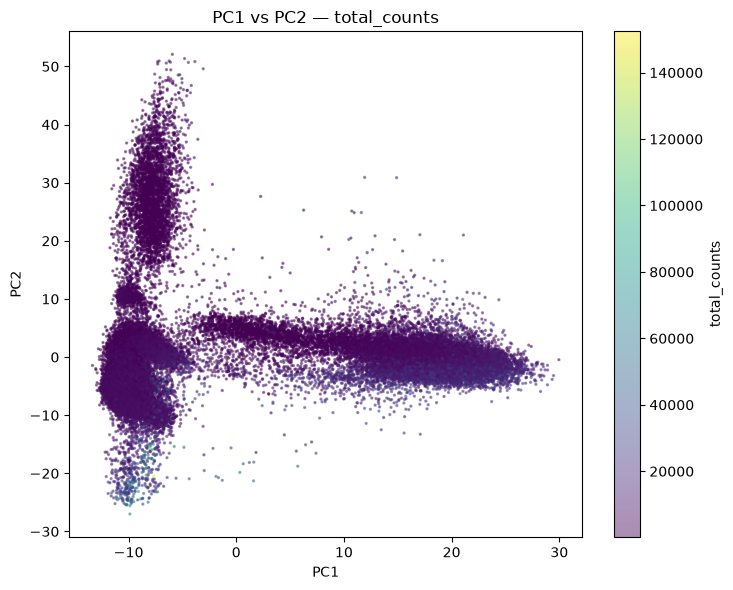

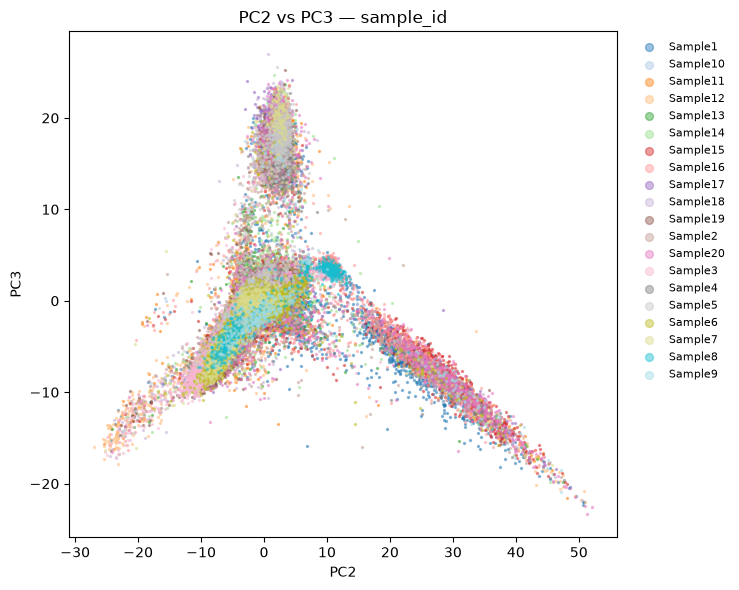

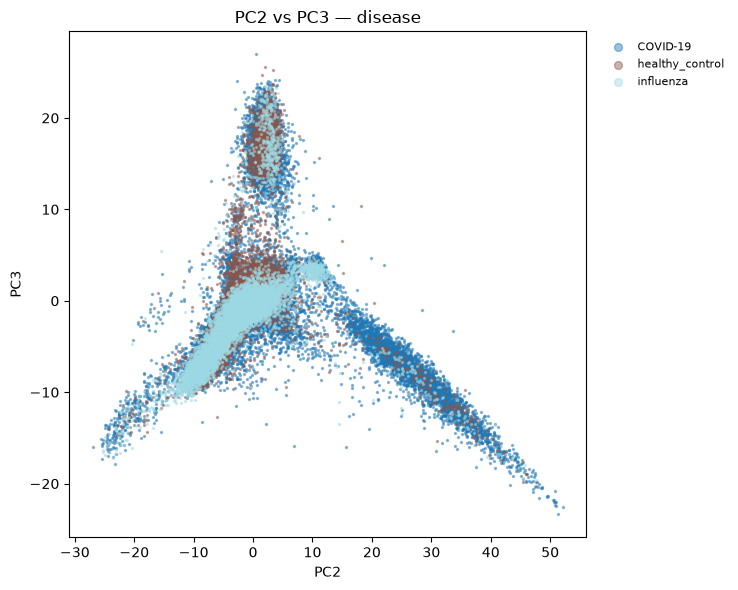

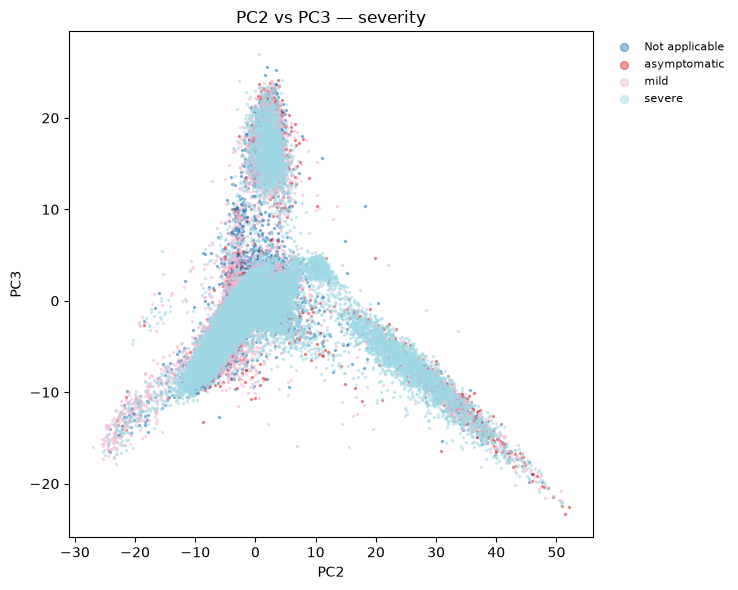

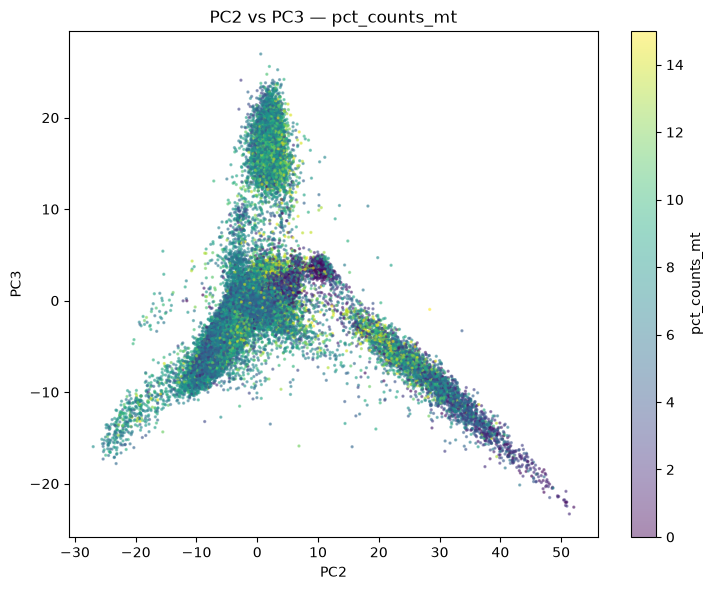

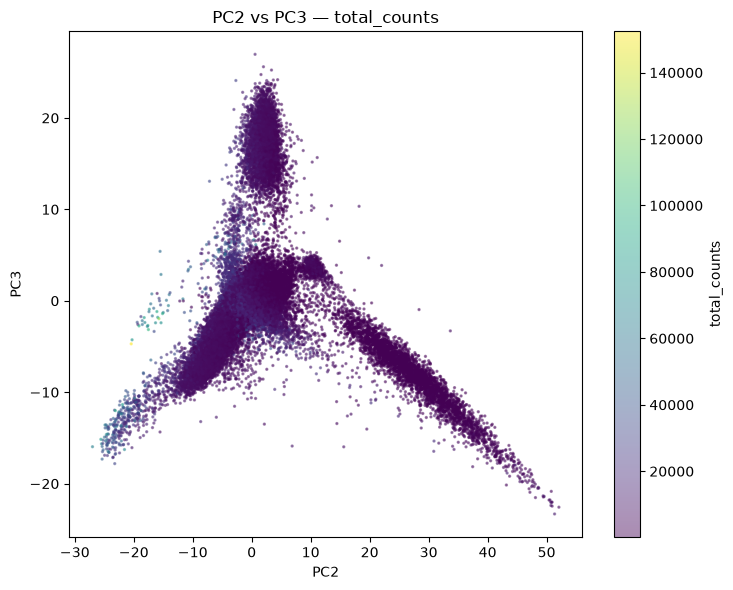

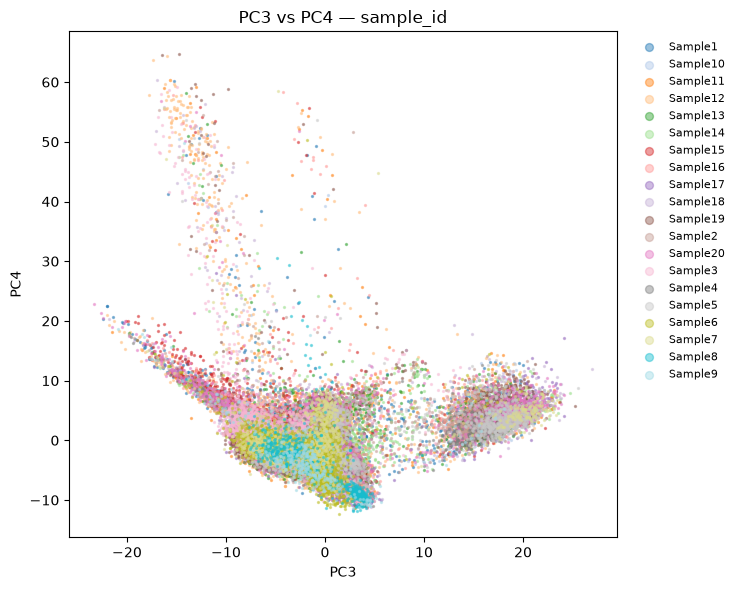

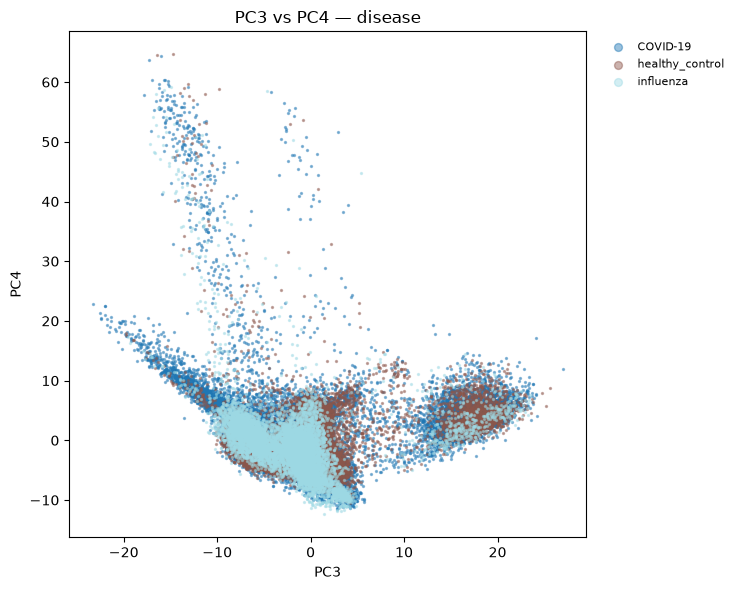

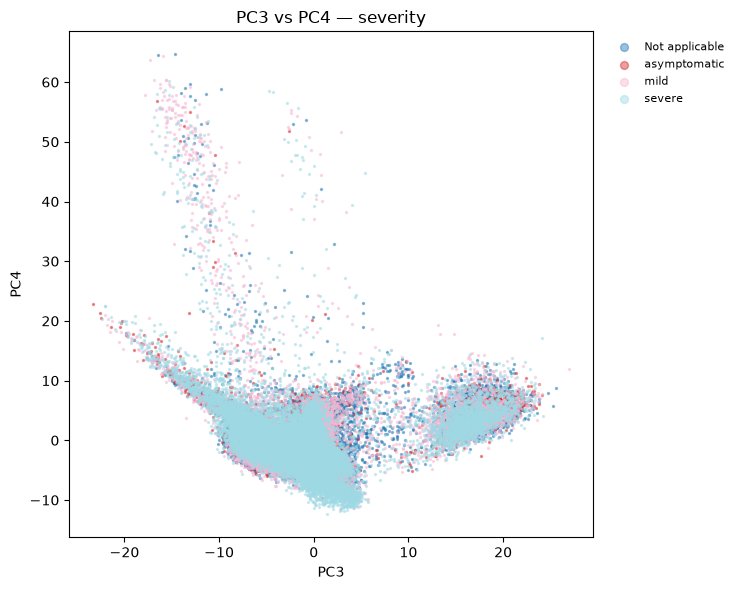

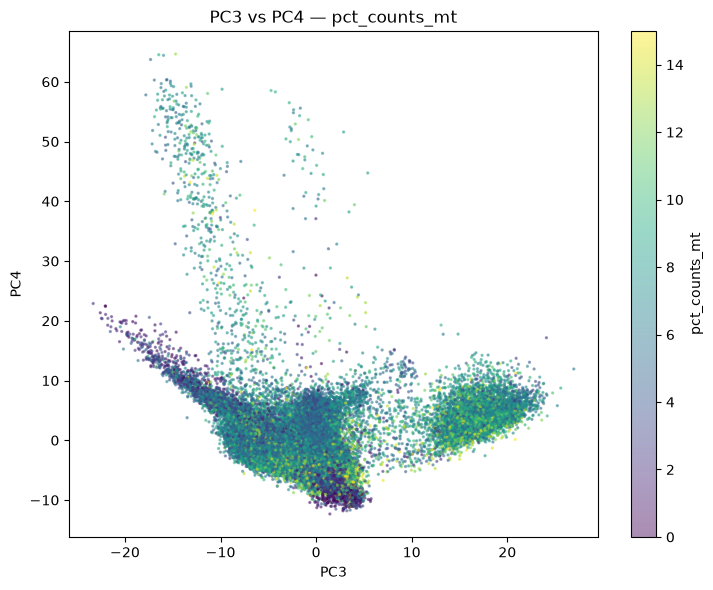

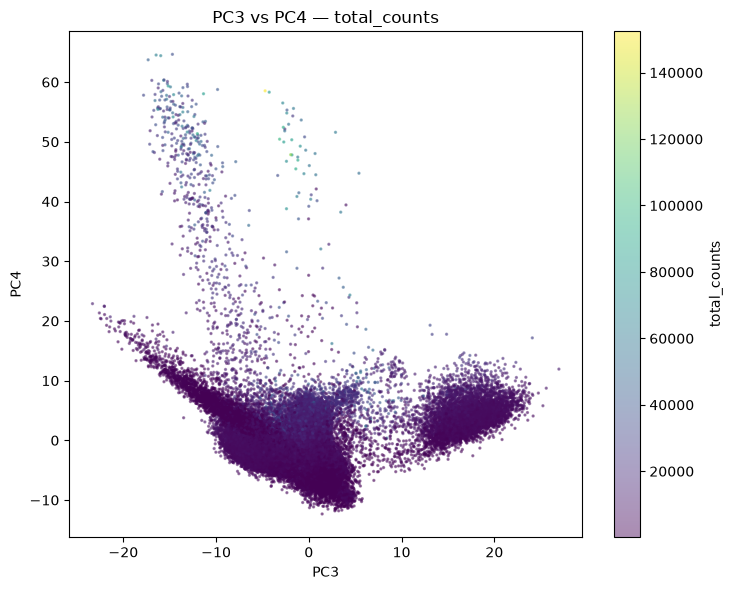

In [8]:
pc_pairs = [(1, 2), (2, 3), (3, 4)]
color_variables = ["sample_id", "disease", "severity", "pct_counts_mt", "total_counts"]

def plot_pca_pair(adata_for_plot, pc_x, pc_y, color_variable, output_path):
    x = adata_for_plot.obsm["X_pca"][:, pc_x - 1]
    y = adata_for_plot.obsm["X_pca"][:, pc_y - 1]
    values = adata_for_plot.obs[color_variable]
    fig, ax = plt.subplots(figsize=(7.5, 6))
    if pd.api.types.is_numeric_dtype(values):
        points = ax.scatter(x, y, c=values.to_numpy(), s=2, alpha=0.45, cmap="viridis", rasterized=True)
        fig.colorbar(points, ax=ax, label=color_variable)
    else:
        categories = values.astype(object).where(values.notna(), "Not applicable").astype(str)
        category_names = sorted(categories.unique())
        colors = plt.get_cmap("tab20")(np.linspace(0, 1, max(len(category_names), 2)))
        for category, color in zip(category_names, colors):
            mask = categories.to_numpy() == category
            ax.scatter(x[mask], y[mask], s=2, alpha=0.45, color=color, label=category, rasterized=True)
        ax.legend(markerscale=4, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=8)
    ax.set_xlabel(f"PC{pc_x}")
    ax.set_ylabel(f"PC{pc_y}")
    ax.set_title(f"PC{pc_x} vs PC{pc_y} — {color_variable}")
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

for pc_x, pc_y in pc_pairs:
    for color_variable in color_variables:
        plot_pca_pair(
            adata_hvg, pc_x, pc_y, color_variable,
            figure_dir / f"PC{pc_x}_PC{pc_y}_{color_variable}.png",
        )

## Résumé descriptif

In [9]:
dominant_rows = []
for pc_index in range(5):
    positions = np.argsort(np.abs(loadings[:, pc_index]))[-5:][::-1]
    dominant_rows.append({
        "PC": f"PC{pc_index + 1}",
        "variance_explained_percent": 100 * variance_ratio[pc_index],
        "dominant_genes_by_absolute_loading": ", ".join(adata_hvg.var_names[positions]),
    })
dominant_pc_summary = pd.DataFrame(dominant_rows)
display(dominant_pc_summary)

def categorical_eta_squared(values, groups):
    frame = pd.DataFrame({"value": values, "group": groups}).dropna()
    grand_mean = frame["value"].mean()
    ss_total = ((frame["value"] - grand_mean) ** 2).sum()
    ss_between = frame.groupby("group", observed=True)["value"].agg(
        lambda x: len(x) * (x.mean() - grand_mean) ** 2
    ).sum()
    return float(ss_between / ss_total) if ss_total > 0 else np.nan

sample_eta_squared = pd.Series({
    f"PC{i}": categorical_eta_squared(adata_hvg.obsm["X_pca"][:, i - 1], adata_hvg.obs["sample_id"])
    for i in range(1, 11)
}, name="eta_squared_sample_id")
display(sample_eta_squared.to_frame())

strong_qc = pc_qc_spearman.stack()[pc_qc_spearman.stack().abs() >= 0.5]
qc_sentence = (
    "Aucune corrélation de Spearman absolue ≥ 0,50 n'est observée entre PC1-PC10 et total_counts, n_genes_by_counts ou pct_counts_mt."
    if strong_qc.empty else
    "Corrélations de Spearman absolues ≥ 0,50 : " + ", ".join(
        f"{pc}/{metric}={value:.2f}" for (pc, metric), value in strong_qc.items()
    ) + "."
)
max_sample_pc = sample_eta_squared.idxmax()
max_sample_eta = sample_eta_squared.max()
sample_sentence = (
    f"L'association descriptive maximale avec sample_id parmi PC1-PC10 est {max_sample_pc} "
    f"(eta²={max_sample_eta:.3f}). Les projections doivent être examinées pour juger la séparation visuelle; "
    "une éventuelle séparation par échantillon n'est pas interprétée automatiquement comme un effet de batch."
)
display(Markdown(
    f"Les cinq premières PC expliquent respectivement **{', '.join(f'{100*x:.2f} %' for x in variance_ratio[:5])}** de la variance. "
    + qc_sentence + " " + sample_sentence
))

,PC,variance_explained_percent,dominant_genes_by_absolute_loading
0,PC1,9.734973,"FCN1, LYZ, AIF1, SERPINA1, CTSS"
1,PC2,4.152426,"PF4, GNG11, CAVIN2, TUBB1, GP9"
2,PC3,2.738772,"CD79A, MS4A1, IGHM, TNFRSF13C, LINC00926"
3,PC4,1.880218,"TYMS, PCLAF, RRM2, MKI67, TK1"
4,PC5,1.310037,"FCGR3A, HLA-DPB1, HLA-DPA1, RHOC, KLRF1"


,eta_squared_sample_id
PC1,0.104664
PC2,0.159780
PC3,0.046151
PC4,0.040602
PC5,0.103158
PC6,0.137343
PC7,0.150268
PC8,0.362041
PC9,0.245411
PC10,0.121056


Les cinq premières PC expliquent respectivement **9.73 %, 4.15 %, 2.74 %, 1.88 %, 1.31 %** de la variance. Aucune corrélation de Spearman absolue ≥ 0,50 n'est observée entre PC1-PC10 et total_counts, n_genes_by_counts ou pct_counts_mt. L'association descriptive maximale avec sample_id parmi PC1-PC10 est PC8 (eta²=0.362). Les projections doivent être examinées pour juger la séparation visuelle; une éventuelle séparation par échantillon n'est pas interprétée automatiquement comme un effet de batch.

**Observation des projections par échantillon.** Dans les plans PC1–PC2, PC2–PC3 et PC3–PC4, les 20 échantillons se chevauchent largement : aucune séparation globale et uniforme par sample_id n'est visible. Certaines régions ou branches montrent néanmoins des enrichissements localisés pour quelques échantillons. Par ailleurs, l'association quantitative avec sample_id est plus marquée pour PC8 (eta² = 0,362) et PC9 (eta² = 0,245) que pour PC1–PC4. Ces observations sont rapportées pour interprétation scientifique et ne sont pas qualifiées automatiquement d'effet de batch.

## Investigation of sample-associated PCs

In [10]:
sample_pc_figure_dir = figure_dir / "sample_associated_pcs"
sample_pc_figure_dir.mkdir(parents=True, exist_ok=True)

def extreme_loadings_table(pc_number, n_genes=20):
    pc_loadings = adata_hvg.varm["PCs"][:, pc_number - 1]
    nbatches = (
        adata_hvg.var["highly_variable_nbatches"].to_numpy()
        if "highly_variable_nbatches" in adata_hvg.var else np.full(adata_hvg.n_vars, np.nan)
    )
    rows = []
    for direction, positions in [
        ("positive", np.argsort(pc_loadings)[-n_genes:][::-1]),
        ("negative", np.argsort(pc_loadings)[:n_genes]),
    ]:
        for rank, position in enumerate(positions, start=1):
            rows.append({
                "PC": f"PC{pc_number}",
                "direction": direction,
                "rank": rank,
                "gene_name": adata_hvg.var_names[position],
                "loading": pc_loadings[position],
                "highly_variable_nbatches": nbatches[position],
            })
    return pd.DataFrame(rows)

pc8_extreme_loadings = extreme_loadings_table(8)
pc9_extreme_loadings = extreme_loadings_table(9)
for pc_name, table in [("PC8", pc8_extreme_loadings), ("PC9", pc9_extreme_loadings)]:
    print(f"{pc_name} — 20 loadings positifs les plus élevés :")
    display(table.loc[table["direction"] == "positive", ["gene_name", "loading", "highly_variable_nbatches"]])
    print(f"{pc_name} — 20 loadings négatifs les plus élevés en valeur absolue :")
    display(table.loc[table["direction"] == "negative", ["gene_name", "loading", "highly_variable_nbatches"]])

PC8 — 20 loadings positifs les plus élevés :


,gene_name,loading,highly_variable_nbatches
0,BHLHE40,0.102730,8
1,NR4A2,0.091651,17
2,DUSP2,0.087812,18
3,ZNF331,0.087591,16
4,RGCC,0.083718,19
5,CREM,0.083677,15
6,ZFP36,0.083301,12
7,IER2,0.078914,10
8,MAFF,0.078659,9
9,JUN,0.077707,19


PC8 — 20 loadings négatifs les plus élevés en valeur absolue :


,gene_name,loading,highly_variable_nbatches
20,ACTB,-0.097122,14
21,ACTG1,-0.080450,19
22,CLU,-0.078694,17
23,ARPC1B,-0.077719,8
24,OAZ1,-0.071119,8
25,PKM,-0.070609,14
26,MYL9,-0.070250,18
27,TMSB4X,-0.069056,9
28,GAPDH,-0.067974,19
29,PFN1,-0.063674,8


PC9 — 20 loadings positifs les plus élevés :


,gene_name,loading,highly_variable_nbatches
0,MYL9,0.118045,18
1,PARVB,0.098702,10
2,TREML1,0.092160,18
3,CD9,0.090006,19
4,ITGA2B,0.087085,17
5,ACTG1,0.084322,19
6,GAPDH,0.080039,19
7,GSN,0.080031,16
8,ACTB,0.078934,14
9,NRGN,0.078513,18


PC9 — 20 loadings négatifs les plus élevés en valeur absolue :


,gene_name,loading,highly_variable_nbatches
20,EPSTI1,-0.086593,10
21,GBP1,-0.085298,19
22,NFE2,-0.081281,15
23,DAB2,-0.079712,19
24,INKA1,-0.079333,12
25,OR2B6,-0.078974,9
26,HIST1H2AE,-0.077074,13
27,HIST1H3H,-0.075206,19
28,TSC22D1,-0.075030,18
29,VAMP5,-0.074338,14


In [11]:
sample_pc_scores = pd.DataFrame({
    "sample_id": adata_hvg.obs["sample_id"].to_numpy(),
    "PC8": adata_hvg.obsm["X_pca"][:, 7],
    "PC9": adata_hvg.obsm["X_pca"][:, 8],
}, index=adata_hvg.obs_names)
sample_pc_summary = (
    sample_pc_scores.groupby("sample_id", observed=True)
    .agg(
        n_cells=("PC8", "size"),
        mean_PC8=("PC8", "mean"),
        median_PC8=("PC8", "median"),
        mean_PC9=("PC9", "mean"),
        median_PC9=("PC9", "median"),
    )
    .reset_index()
)
print("Samples triés par score moyen PC8 :")
display(sample_pc_summary.sort_values(["mean_PC8", "mean_PC9"]))
print("Samples triés par score moyen PC9 :")
display(sample_pc_summary.sort_values(["mean_PC9", "mean_PC8"]))

Samples triés par score moyen PC8 :


,sample_id,n_cells,mean_PC8,median_PC8,mean_PC9,median_PC9
13,Sample3,4879,-4.672374,-4.800807,-3.821357,-3.640246
10,Sample19,4011,-1.889333,-1.964337,-0.660370,-0.450738
16,Sample6,2569,-1.839507,-1.761592,-0.576257,-0.638699
7,Sample16,1866,-1.447065,-1.341828,1.501218,0.572307
0,Sample1,4409,-1.328977,-0.868740,2.259938,1.230708
17,Sample7,1026,-0.923499,-0.863383,-1.096063,-0.532719
5,Sample14,4481,-0.731433,-0.778111,0.662601,0.536260
4,Sample13,4539,-0.096382,-0.085717,0.796527,0.668627
14,Sample4,1315,-0.094145,-0.069276,2.432138,1.726120
6,Sample15,1486,0.032566,-1.132431,-2.003914,-0.484044


Samples triés par score moyen PC9 :


,sample_id,n_cells,mean_PC8,median_PC8,mean_PC9,median_PC9
13,Sample3,4879,-4.672374,-4.800807,-3.821357,-3.640246
8,Sample17,1321,2.680419,2.898988,-3.798784,-3.343918
18,Sample8,648,1.635337,1.681295,-2.375869,-2.275149
6,Sample15,1486,0.032566,-1.132431,-2.003914,-0.484044
17,Sample7,1026,-0.923499,-0.863383,-1.096063,-0.532719
12,Sample20,4346,1.681920,1.519208,-1.048727,-0.830304
19,Sample9,398,2.050698,2.164550,-0.966708,-0.111940
10,Sample19,4011,-1.889333,-1.964337,-0.660370,-0.450738
16,Sample6,2569,-1.839507,-1.761592,-0.576257,-0.638699
15,Sample5,4324,0.591608,0.343473,0.393031,0.206743


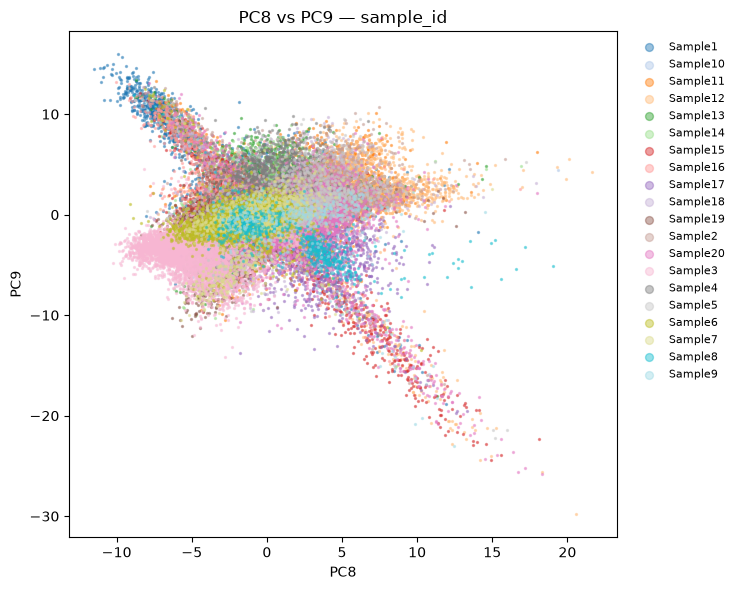

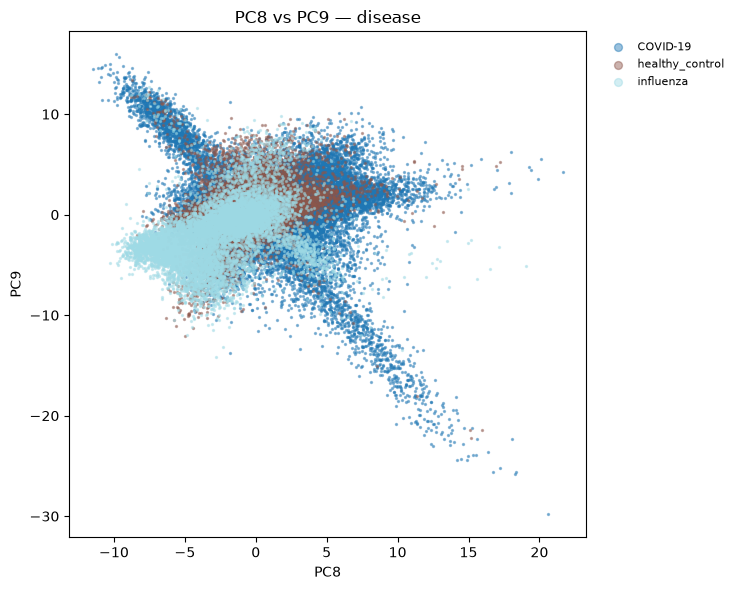

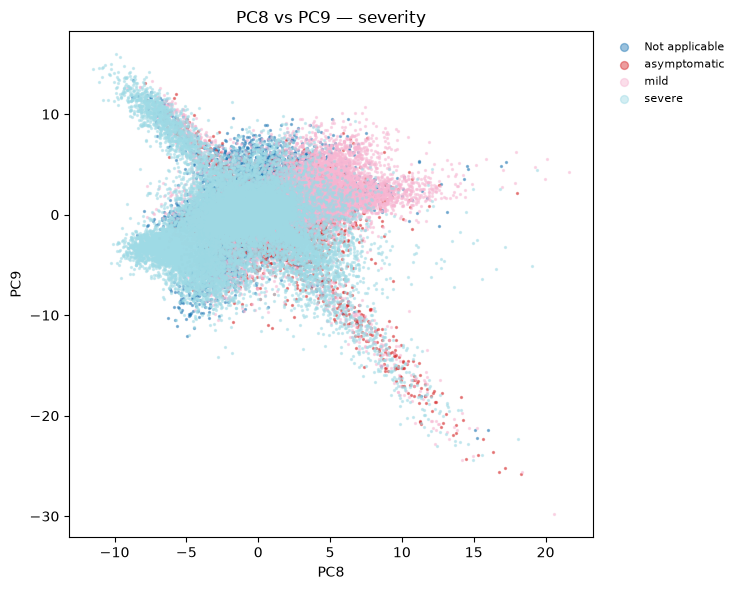

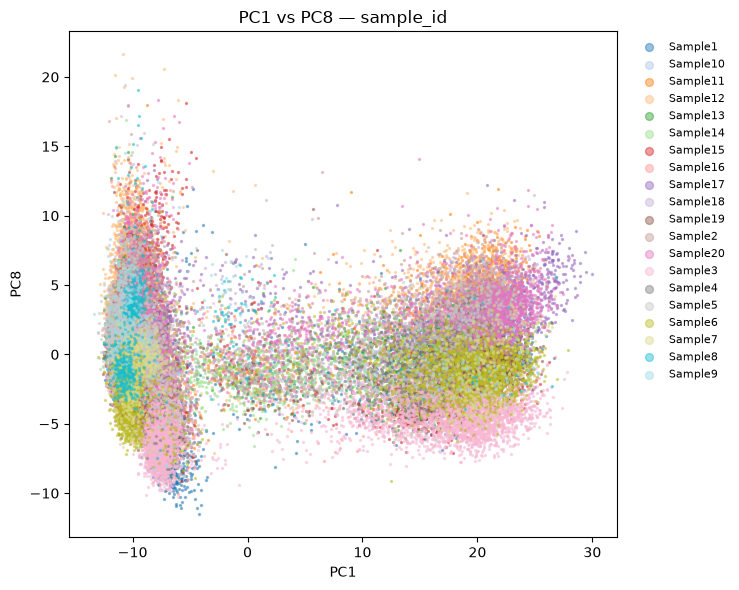

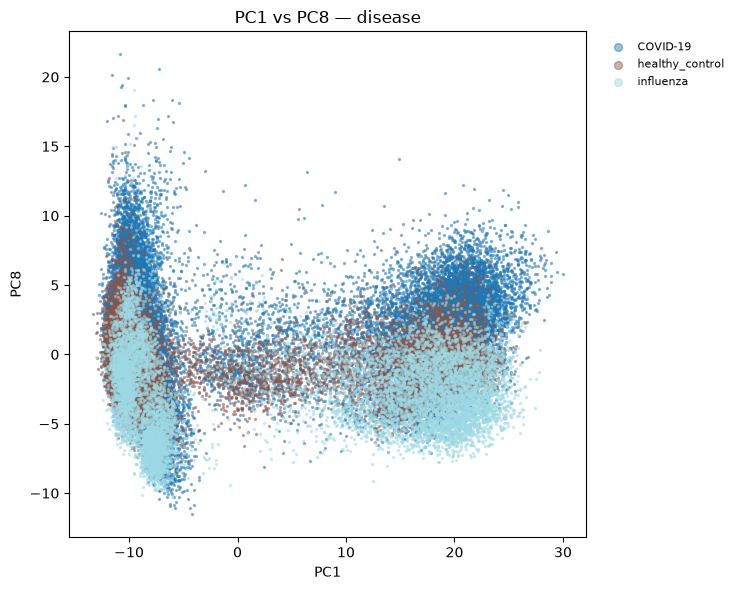

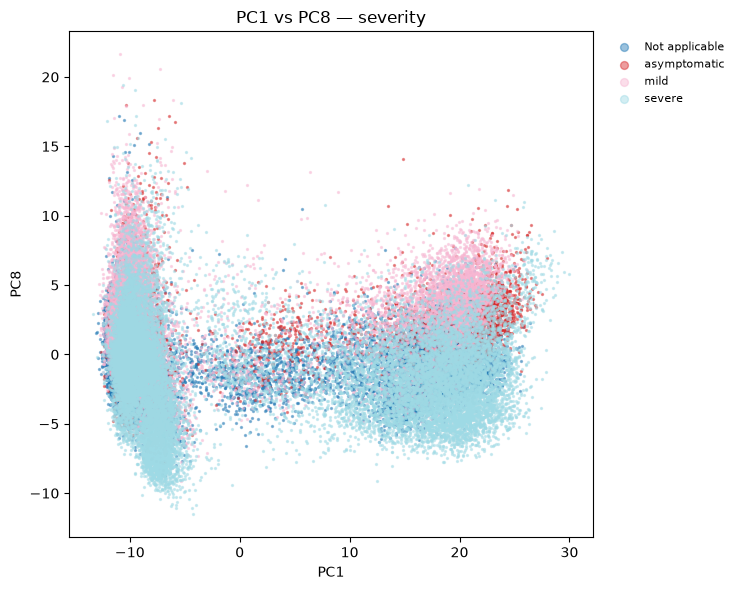

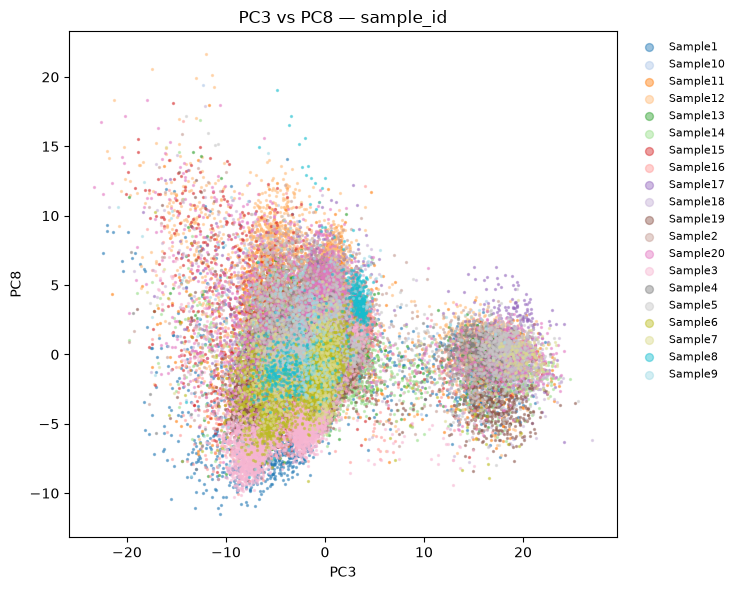

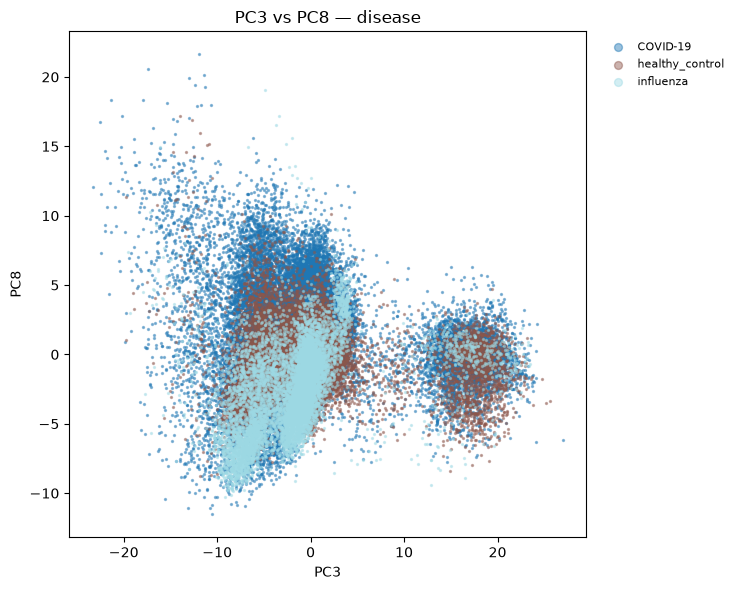

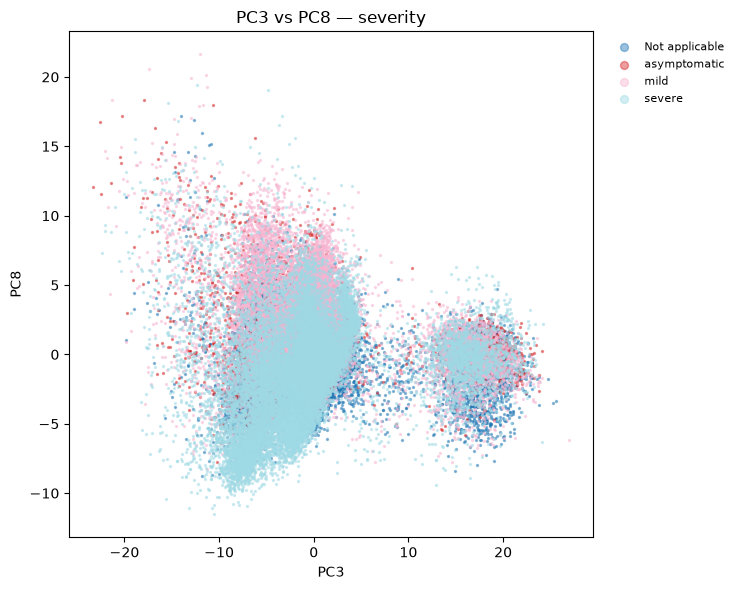

In [12]:
sample_pc_pairs = [(8, 9), (1, 8), (3, 8)]
sample_pc_colors = ["sample_id", "disease", "severity"]
for pc_x, pc_y in sample_pc_pairs:
    for color_variable in sample_pc_colors:
        plot_pca_pair(
            adata_hvg, pc_x, pc_y, color_variable,
            sample_pc_figure_dir / f"PC{pc_x}_PC{pc_y}_{color_variable}.png",
        )

In [13]:
def categorical_eta_squared_with_missing(values, groups):
    groups_complete = pd.Series(groups, index=adata_hvg.obs_names).astype(object)
    groups_complete = groups_complete.where(groups_complete.notna(), "Not applicable").astype(str)
    return categorical_eta_squared(values, groups_complete)

eta_rows = []
for pc_number in [8, 9]:
    scores = adata_hvg.obsm["X_pca"][:, pc_number - 1]
    for variable in ["sample_id", "disease", "severity"]:
        eta_rows.append({
            "PC": f"PC{pc_number}",
            "variable": variable,
            "eta_squared": categorical_eta_squared_with_missing(scores, adata_hvg.obs[variable]),
        })
pc8_pc9_eta_squared = pd.DataFrame(eta_rows)
display(pc8_pc9_eta_squared.pivot(index="PC", columns="variable", values="eta_squared"))
print("Ces eta² sont descriptifs et ne constituent pas une preuve d'effet de batch.")

variable,disease,sample_id,severity
PC,,,
PC8,0.172255,0.362041,0.189563
PC9,0.068312,0.245411,0.042919


Ces eta² sont descriptifs et ne constituent pas une preuve d'effet de batch.


### Résumé descriptif

Les loadings positifs de PC8 (notamment BHLHE40, NR4A2, DUSP2, ZFP36, JUN, CD69, IER3 et TNFAIP3) suggèrent un programme de réponse immédiate et d'activation, opposé sur son versant négatif à des composantes cytosquelettiques et plaquettaires. PC9 est dominée positivement par une signature plaquettaire ou mégacaryocytaire (MYL9, TREML1, ITGA2B, PPBP, SPARC) et négativement par des gènes de réponse interféron (EPSTI1, GBP1, OAS1, GBP5), associés à plusieurs histones. Ces interprétations restent indicatives et peuvent également refléter des différences de composition cellulaire.

Sample3 occupe l'extrême négatif moyen de PC8 (-4,67), tandis que Sample12 occupe l'extrême positif (+3,41). Pour PC9, Sample3 et Sample17 présentent les moyennes les plus négatives (-3,82 et -3,80), tandis que Sample4 et Sample1 présentent les plus positives (+2,43 et +2,26). L'association de PC8 correspond aussi partiellement à disease (eta² = 0,172) et severity (eta² = 0,190), bien que l'association avec sample_id soit plus élevée (eta² = 0,362). Pour PC9, les associations avec disease (eta² = 0,068) et severity (eta² = 0,043) sont faibles par rapport à sample_id (eta² = 0,245). Aucune de ces associations descriptives n'est interprétée automatiquement comme un effet de batch et aucune correction n'a été appliquée.

## PCA diagnostics for PC11–PC20

In [14]:
top_absolute_loading_rows = []
for pc_index in range(20):
    pc_loadings = loadings[:, pc_index]
    top_positions = np.argsort(np.abs(pc_loadings))[-5:][::-1]
    for rank, position in enumerate(top_positions, start=1):
        top_absolute_loading_rows.append({
            "PC": f"PC{pc_index + 1}",
            "rank_by_absolute_loading": rank,
            "gene_name": adata_hvg.var_names[position],
            "loading": pc_loadings[position],
            "absolute_loading": abs(pc_loadings[position]),
        })
top_absolute_loadings_pc1_pc20 = pd.DataFrame(top_absolute_loading_rows)
top_absolute_loadings_pc11_pc20 = top_absolute_loadings_pc1_pc20.loc[
    top_absolute_loadings_pc1_pc20["PC"].isin([f"PC{i}" for i in range(11, 21)])
].copy()
print("Top 5 des loadings absolus pour PC11 à PC20 :")
display(top_absolute_loadings_pc11_pc20)

Top 5 des loadings absolus pour PC11 à PC20 :


,PC,rank_by_absolute_loading,gene_name,loading,absolute_loading
50,PC11,1,HBB,0.158396,0.158396
51,PC11,2,ALAS2,0.146550,0.146550
52,PC11,3,HBA1,0.143396,0.143396
53,PC11,4,HBA2,0.142145,0.142145
54,PC11,5,AHSP,0.135647,0.135647
55,PC12,1,IFI44L,0.118221,0.118221
56,PC12,2,ISG15,0.105499,0.105499
57,PC12,3,AREG,-0.102361,0.102361
58,PC12,4,SIGLEC1,0.099861,0.099861
59,PC12,5,APOBEC3A,0.097134,0.097134


In [15]:
pc_names_20 = [f"PC{i}" for i in range(1, 21)]
pc_qc_data_20 = pd.DataFrame(
    adata_hvg.obsm["X_pca"][:, :20],
    index=adata_hvg.obs_names,
    columns=pc_names_20,
)
pc_qc_data_20 = pd.concat([pc_qc_data_20, adata_hvg.obs[qc_metrics]], axis=1)
pc_qc_spearman_pc1_pc20 = pc_qc_data_20.corr(method="spearman").loc[pc_names_20, qc_metrics]

sample_eta_squared_pc1_pc20 = pd.Series({
    f"PC{i}": categorical_eta_squared(
        adata_hvg.obsm["X_pca"][:, i - 1], adata_hvg.obs["sample_id"]
    )
    for i in range(1, 21)
}, name="eta_squared_sample_id")

print("Corrélations de Spearman PC11 à PC20 avec les métriques QC :")
display(pc_qc_spearman_pc1_pc20.loc[[f"PC{i}" for i in range(11, 21)]])
print("Eta²(sample_id) pour PC11 à PC20 :")
display(sample_eta_squared_pc1_pc20.loc[[f"PC{i}" for i in range(11, 21)]].to_frame())

Corrélations de Spearman PC11 à PC20 avec les métriques QC :


,total_counts,n_genes_by_counts,pct_counts_mt
PC11,0.104647,0.067014,-0.096615
PC12,-0.233641,-0.176176,-0.005519
PC13,0.001722,0.000966,0.099634
PC14,0.040221,0.065665,-0.108133
PC15,-0.170949,-0.183310,0.074353
PC16,0.068297,0.051389,0.023347
PC17,-0.134604,-0.095729,0.081531
PC18,-0.035483,-0.024331,-0.032399
PC19,-0.021653,0.005136,-0.005050
PC20,-0.009761,-0.001786,0.100683


Eta²(sample_id) pour PC11 à PC20 :


,eta_squared_sample_id
PC11,0.315932
PC12,0.202330
PC13,0.164832
PC14,0.135338
PC15,0.119995
PC16,0.190892
PC17,0.126039
PC18,0.101962
PC19,0.175351
PC20,0.075121


In [16]:
top_five_gene_strings = (
    top_absolute_loadings_pc1_pc20.sort_values(["PC", "rank_by_absolute_loading"])
    .groupby("PC", sort=False)["gene_name"]
    .agg(", ".join)
)
pca_diagnostic_pc1_pc20 = pd.DataFrame({
    "PC": pc_names_20,
    "variance_explained_percent": 100 * variance_ratio[:20],
    "cumulative_variance_percent": 100 * cumulative_variance[:20],
    "eta_squared_sample_id": sample_eta_squared_pc1_pc20.reindex(pc_names_20).to_numpy(),
    "spearman_total_counts": pc_qc_spearman_pc1_pc20["total_counts"].reindex(pc_names_20).to_numpy(),
    "spearman_n_genes_by_counts": pc_qc_spearman_pc1_pc20["n_genes_by_counts"].reindex(pc_names_20).to_numpy(),
    "spearman_pct_counts_mt": pc_qc_spearman_pc1_pc20["pct_counts_mt"].reindex(pc_names_20).to_numpy(),
    "top_5_genes_by_absolute_loading": top_five_gene_strings.reindex(pc_names_20).to_numpy(),
})
diagnostic_table_path = table_dir / "pca_diagnostic_pc1_pc20.csv"
pca_diagnostic_pc1_pc20.to_csv(diagnostic_table_path, index=False)
display(pca_diagnostic_pc1_pc20)
print("Table sauvegardée :", diagnostic_table_path)

,PC,variance_explained_percent,cumulative_variance_percent,eta_squared_sample_id,spearman_total_counts,spearman_n_genes_by_counts,spearman_pct_counts_mt,top_5_genes_by_absolute_loading
0,PC1,9.734973,9.734973,0.104664,0.379577,0.413876,-0.081069,"FCN1, LYZ, AIF1, SERPINA1, CTSS"
1,PC2,4.152426,13.887399,0.159780,-0.368475,-0.484101,-0.037048,"PF4, GNG11, CAVIN2, TUBB1, GP9"
2,PC3,2.738772,16.626171,0.046151,0.112125,-0.052682,0.003642,"CD79A, MS4A1, IGHM, TNFRSF13C, LINC00926"
3,PC4,1.880218,18.506389,0.040602,0.437632,0.444187,-0.105879,"TYMS, PCLAF, RRM2, MKI67, TK1"
4,PC5,1.310037,19.816426,0.103158,0.094848,0.216880,-0.061270,"FCGR3A, HLA-DPB1, HLA-DPA1, RHOC, KLRF1"
5,PC6,1.041023,20.857449,0.137343,0.206021,0.096781,-0.071724,"IL7R, CDKN1C, MAL, TRAC, RCAN3"
6,PC7,0.866615,21.724063,0.150268,-0.336075,-0.282913,0.028816,"ALAS2, HBA1, HBA2, AHSP, CA1"
7,PC8,0.666082,22.390145,0.362041,-0.030227,-0.030266,-0.151730,"BHLHE40, ACTB, NR4A2, DUSP2, ZNF331"
8,PC9,0.631182,23.021327,0.245411,0.009080,0.021837,0.063436,"MYL9, PARVB, TREML1, CD9, ITGA2B"
9,PC10,0.561437,23.582764,0.121056,-0.195901,-0.207570,0.083313,"NFKBIZ, ALAS2, TNFAIP3, NFKBIA, AHSP"


Table sauvegardée : ../results/tables/pca/pca_diagnostic_pc1_pc20.csv


In [17]:
diagnostic_pc11_pc20 = pca_diagnostic_pc1_pc20.iloc[10:20].copy()
largest_eta_row = diagnostic_pc11_pc20.loc[diagnostic_pc11_pc20["eta_squared_sample_id"].idxmax()]
qc_columns_diagnostic = [
    "spearman_total_counts",
    "spearman_n_genes_by_counts",
    "spearman_pct_counts_mt",
]
diagnostic_qc_by_pc = diagnostic_pc11_pc20.set_index("PC")[qc_columns_diagnostic]
largest_qc_location = diagnostic_qc_by_pc.abs().stack().idxmax()
largest_qc_pc, largest_qc_metric = largest_qc_location
largest_qc_value = diagnostic_qc_by_pc.loc[largest_qc_pc, largest_qc_metric]
display(Markdown(
    f"Pour PC11–PC20, la variance expliquée individuelle s'étend de "
    f"**{diagnostic_pc11_pc20['variance_explained_percent'].min():.3f} %** à "
    f"**{diagnostic_pc11_pc20['variance_explained_percent'].max():.3f} %**. "
    f"L'association descriptive maximale avec sample_id dans cet intervalle est observée pour "
    f"**{largest_eta_row['PC']}** (eta² = **{largest_eta_row['eta_squared_sample_id']:.3f}**). "
    f"La corrélation QC absolue la plus élevée est **{largest_qc_pc}/{largest_qc_metric}** "
    f"(rho = **{largest_qc_value:.3f}**). Ces résultats sont descriptifs : aucune PC n'est exclue, "
    "et aucune association avec sample_id n'est automatiquement qualifiée d'effet de batch."
))

Pour PC11–PC20, la variance expliquée individuelle s'étend de **0.220 %** à **0.528 %**. L'association descriptive maximale avec sample_id dans cet intervalle est observée pour **PC11** (eta² = **0.316**). La corrélation QC absolue la plus élevée est **PC12/spearman_total_counts** (rho = **-0.234**). Ces résultats sont descriptifs : aucune PC n'est exclue, et aucune association avec sample_id n'est automatiquement qualifiée d'effet de batch.